# SVD 直觉与 PCA 关系 - 可视化

本 Notebook 生成三张图：
1. SVD 的旋转-拉伸-旋转几何示意
2. 奇异值能量分布
3. PCA 与 SVD 投影结果一致性

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/02_线性代数/assets')

## 图1：SVD 几何直觉（单位圆变换）

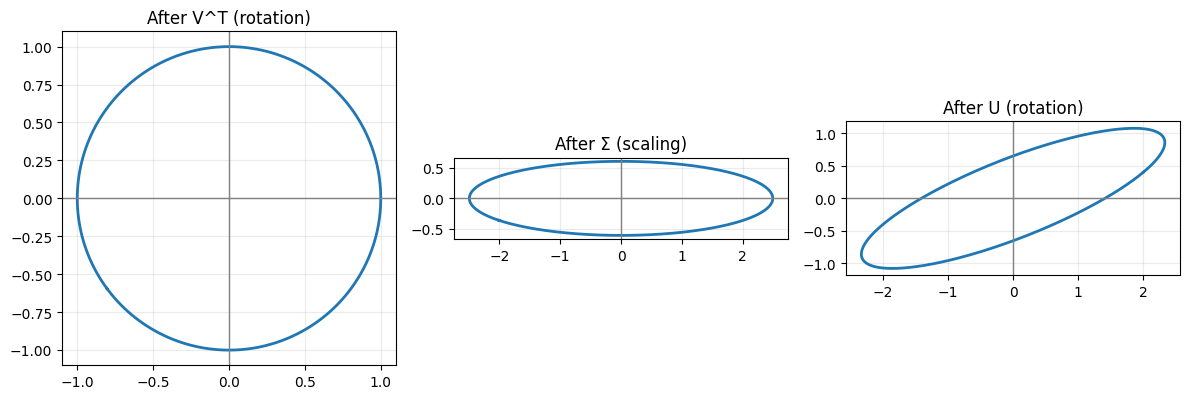

In [2]:
# 构造一个2x2矩阵并做SVD
A = np.array([[2.0, 1.2], [0.4, 1.0]])
U, s, Vt = np.linalg.svd(A)

theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])

# 逐步变换: circle -> V^T -> ΣV^T -> UΣV^T
step1 = Vt @ circle
S = np.diag(s)
step2 = S @ step1
step3 = U @ step2

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
titles = ['After V^T (rotation)', 'After Σ (scaling)', 'After U (rotation)']
datas = [step1, step2, step3]

for ax, data, title in zip(axs, datas, titles):
    ax.plot(data[0], data[1], linewidth=2)
    ax.axhline(0, color='gray', linewidth=1)
    ax.axvline(0, color='gray', linewidth=1)
    ax.set_aspect('equal', 'box')
    ax.grid(alpha=0.25)
    ax.set_title(title)

plt.tight_layout()
plt.savefig(assets_dir / '22_svd_geometry.png', dpi=160)
plt.show()

## 图2：奇异值能量分布

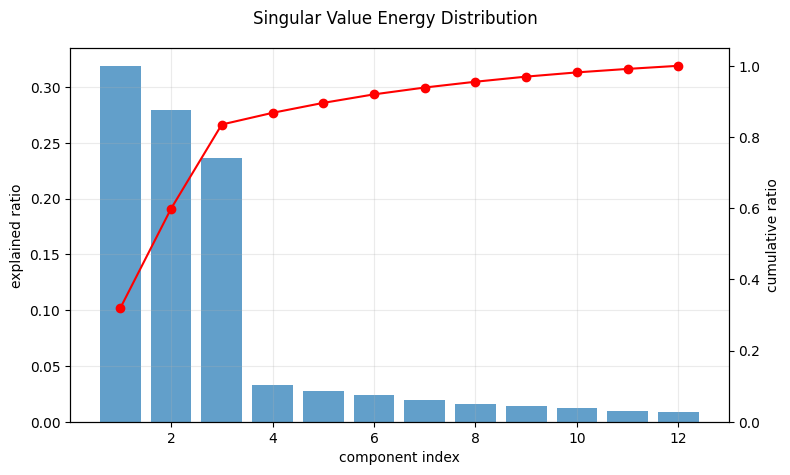

In [3]:
rng = np.random.default_rng(0)
X = rng.normal(size=(80, 12))
# 人为制造低秩结构
X[:, 3:] *= 0.25

_, svals, _ = np.linalg.svd(X, full_matrices=False)
energy = svals**2
ratio = energy / energy.sum()
cum_ratio = np.cumsum(ratio)

fig, ax1 = plt.subplots(figsize=(8,4.8))
ax1.bar(np.arange(1, len(svals)+1), ratio, alpha=0.7, label='explained ratio')
ax1.set_xlabel('component index')
ax1.set_ylabel('explained ratio')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(np.arange(1, len(svals)+1), cum_ratio, 'r-o', label='cumulative ratio')
ax2.set_ylabel('cumulative ratio')
ax2.set_ylim(0, 1.05)

fig.suptitle('Singular Value Energy Distribution')
fig.tight_layout()
plt.savefig(assets_dir / '23_singular_values_energy.png', dpi=160)
plt.show()

## 图3：PCA 与 SVD 投影一致性

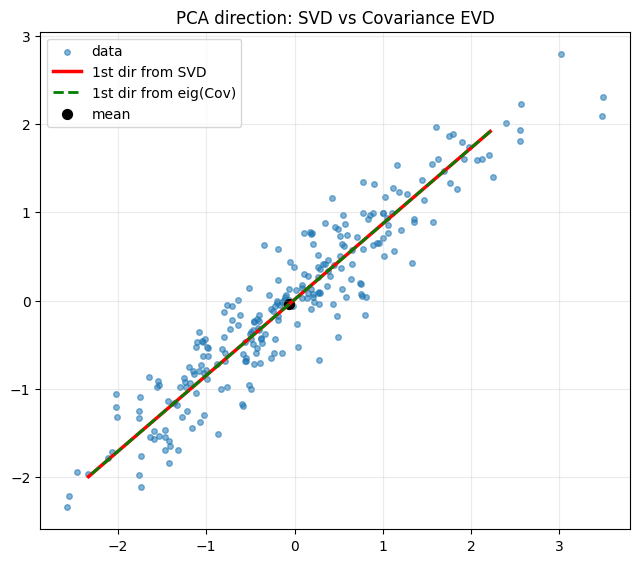

In [4]:
# 2D数据
rng = np.random.default_rng(42)
n = 250
x1 = rng.normal(0, 1.2, n)
x2 = 0.8*x1 + rng.normal(0, 0.35, n)
D = np.column_stack([x1, x2])
Dc = D - D.mean(axis=0, keepdims=True)

# SVD
U, s, Vt = np.linalg.svd(Dc, full_matrices=False)
v1 = Vt[0]  # 第一主方向

# 协方差特征分解
Cov = (Dc.T @ Dc) / len(Dc)
eigvals, eigvecs = np.linalg.eigh(Cov)
v1_eig = eigvecs[:, np.argmax(eigvals)]

# 消除符号不确定性（方向可正可负）
if np.dot(v1, v1_eig) < 0:
    v1_eig = -v1_eig

m = D.mean(axis=0)
scale = 3.0
p1, p2 = m - scale*v1, m + scale*v1
q1, q2 = m - scale*v1_eig, m + scale*v1_eig

plt.figure(figsize=(6.5,6))
plt.scatter(D[:,0], D[:,1], s=16, alpha=0.55, label='data')
plt.plot([p1[0],p2[0]],[p1[1],p2[1]], 'r-', linewidth=2.5, label='1st dir from SVD')
plt.plot([q1[0],q2[0]],[q1[1],q2[1]], 'g--', linewidth=2.0, label='1st dir from eig(Cov)')
plt.scatter([m[0]],[m[1]], c='black', s=50, label='mean')
plt.gca().set_aspect('equal','box')
plt.grid(alpha=0.25)
plt.title('PCA direction: SVD vs Covariance EVD')
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '24_pca_svd_relation.png', dpi=160)
plt.show()

### 输出文件
- `assets/22_svd_geometry.png`
- `assets/23_singular_values_energy.png`
- `assets/24_pca_svd_relation.png`